In [30]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam

In [47]:
base_dir = 'Resized Image'
train_base_dir = "Augmented Image"
val_base_dir = "Resized Image"

leaf_types = sorted([d for d in os.listdir(train_base_dir) if os.path.isdir(os.path.join(train_base_dir, d))])
health_labels = set()
for leaf in leaf_types:
    subfolder = os.path.join(train_base_dir, leaf)
    health_labels.update([d for d in os.listdir(subfolder) if os.path.isdir(os.path.join(subfolder, d))])
health_labels = sorted(list(health_labels))

print("Leaf types:", leaf_types)
print("Health classes:", health_labels)

num_leaf_classes = len(leaf_types)
num_health_classes = len(health_labels)

Leaf types: ['Camphor', 'HariTaki', 'Neem', 'Sojina']
Health classes: ['Bacterial Spot', 'Healthy Leaf', 'Powdery Mildew', 'Shot Hole', 'Yellow Leaf']


In [88]:
def double_label_generator(base_dir, image_size=(256, 256), batch_size=16, augment=True):
    datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    ) if augment else ImageDataGenerator(rescale=1./255)

    leaf_label_map = {leaf: i for i, leaf in enumerate(leaf_types)}
    health_label_map = {health: i for i, health in enumerate(health_labels)}

    image_paths, leaf_targets, health_targets = [], [], []
    for leaf in leaf_types:
        leaf_folder = os.path.join(base_dir, leaf)
        for health in os.listdir(leaf_folder):
            health_folder = os.path.join(leaf_folder, health)
            if not os.path.isdir(health_folder):
                continue
            for img_name in os.listdir(health_folder):
                if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    image_paths.append(os.path.join(health_folder, img_name))
                    leaf_targets.append(leaf_label_map[leaf])
                    health_targets.append(health_label_map[health])

    image_paths = np.array(image_paths)
    leaf_targets = tf.keras.utils.to_categorical(leaf_targets, num_leaf_classes)
    health_targets = tf.keras.utils.to_categorical(health_targets, num_health_classes)

    while True:
        idx = np.random.randint(0, len(image_paths), batch_size)
        batch_paths = image_paths[idx]
        x_batch = np.zeros((batch_size, *image_size, 3))
        for i, path in enumerate(batch_paths):
            img = tf.keras.utils.load_img(path, target_size=image_size)
            img = tf.keras.utils.img_to_array(img)
            x_batch[i] = img
        x_batch = datagen.standardize(x_batch)

        yield x_batch, {
            'leaf_output': leaf_targets[idx],
            'health_output': health_targets[idx]
        }

In [89]:
train_gen = double_label_generator(train_base_dir, batch_size=16, augment=True)
val_gen   = double_label_generator(val_base_dir, batch_size=16, augment=False)

In [90]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

In [91]:
leaf_output = Dense(num_leaf_classes, activation='softmax', name='leaf_output')(x)
health_output = Dense(num_health_classes, activation='softmax', name='health_output')(x)

model = Model(inputs=base_model.input, outputs=[leaf_output, health_output])

model.compile(
    optimizer='adam',
    loss={
        'leaf_output': 'categorical_crossentropy',
        'health_output': 'categorical_crossentropy'
    },
    metrics=['accuracy']
)

In [92]:
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
]

steps_per_epoch = 200
validation_steps = 100

In [93]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks
)

Epoch 1/50
200/200 [==============================] - 37s 161ms/step - loss: 1.3891 - leaf_output_loss: 0.1789 - health_output_loss: 1.2102 - leaf_output_accuracy: 0.9375 - health_output_accuracy: 0.5306 - val_loss: 1.7308 - val_leaf_output_loss: 0.4601 - val_health_output_loss: 1.2707 - val_leaf_output_accuracy: 0.9319 - val_health_output_accuracy: 0.3688 - lr: 0.0010
Epoch 2/50
200/200 [==============================] - 32s 160ms/step - loss: 0.9848 - leaf_output_loss: 0.0901 - health_output_loss: 0.8947 - leaf_output_accuracy: 0.9672 - health_output_accuracy: 0.6384 - val_loss: 1.0187 - val_leaf_output_loss: 0.0719 - val_health_output_loss: 0.9468 - val_leaf_output_accuracy: 0.9887 - val_health_output_accuracy: 0.5900 - lr: 0.0010
Epoch 3/50
200/200 [==============================] - 32s 158ms/step - loss: 0.9031 - leaf_output_loss: 0.0786 - health_output_loss: 0.8244 - leaf_output_accuracy: 0.9744 - health_output_accuracy: 0.6606 - val_loss: 1.4828 - val_leaf_output_loss: 0.3076 - 

In [94]:
results = model.evaluate(val_gen, steps=100)
print(f"Leaf accuracy: {results[3]:.3f}, Health accuracy: {results[4]:.3f}")

100/100 [==============================] - 11s 104ms/step - loss: 0.4344 - leaf_output_loss: 0.0057 - health_output_loss: 0.4287 - leaf_output_accuracy: 0.9987 - health_output_accuracy: 0.8431
Leaf accuracy: 0.999, Health accuracy: 0.843


1/1 [==============================] - 0s 34ms/step
Predicted Leaf Type   : Neem
Predicted Health Label: Healthy Leaf


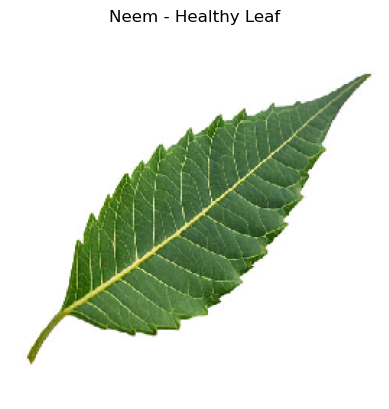

In [97]:
import matplotlib.pyplot as plt

test_image_path = "image.jpg"
image_size = (256, 256)

leaf_types = ['Camphor', 'HariTaki', 'Neem', 'Sojina']
health_labels = ['Bacterial Spot', 'Healthy Leaf', 'Powdery Mildew', 'Shot Hole', 'Yellow Leaf', 'Spot Leaf', 'Powdery Mildew']  # match exactly your dataset folder names

img = tf.keras.utils.load_img(test_image_path, target_size=image_size)
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

pred_leaf, pred_health = model.predict(img_array)

leaf_idx = np.argmax(pred_leaf[0])
health_idx = np.argmax(pred_health[0])

pred_leaf_name = leaf_types[leaf_idx]
pred_health_name = health_labels[health_idx]

print(f"Predicted Leaf Type   : {pred_leaf_name}")
print(f"Predicted Health Label: {pred_health_name}")

plt.imshow(img)
plt.title(f"{pred_leaf_name} - {pred_health_name}")
plt.axis('off')
plt.show()

In [98]:
model.save("doubleLabelLeafDetector.h5")

In [100]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("doubleLabelLeafDetector.tflite", "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\sukri\AppData\Local\Temp\tmplr0a4ljs\assets


INFO:tensorflow:Assets written to: C:\Users\sukri\AppData\Local\Temp\tmplr0a4ljs\assets


In [101]:
model_json = model.to_json()
with open("doubleLabelLeafDetector.json", "w") as json_file:
    json_file.write(model_json)

In [102]:
model.save("doubleLabelLeafDetector", save_format='tf')

INFO:tensorflow:Assets written to: doubleLabelLeafDetector\assets


INFO:tensorflow:Assets written to: doubleLabelLeafDetector\assets
